<a href="https://colab.research.google.com/github/mebre7/house-price-predictor-mlops/blob/colab_branch/notebooks/01_eda_and_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining and visualizing data to uncover patterns, relationships, and insights. It helps in understanding the underlying structure of the data, identifying anomalies, and informing subsequent modeling decisions.

## 1. Load Data from PostgreSQL

In [67]:
from sqlalchemy import create_engine, text
import pandas as pd
from urllib.parse import quote_plus
from google.colab import userdata

In [68]:
DB_USER = userdata.get("SUPABASE_USER")
DB_PASSWORD = quote_plus(userdata.get("SUPABASE_PASSWORD"))
DB_HOST = userdata.get("SUPABASE_HOST")
DB_PORT = userdata.get("SUPABASE_PORT")
DB_NAME = userdata.get("SUPABASE_NAME")

# 2. Build SQLAlchemy connection string
DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)
with engine.connect() as conn:
    df = pd.read_sql(
        text("SELECT * FROM housing_data"),
        conn
    )

df.head()

,Order,PID,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,...,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,None,IR1,Lvl,...,0,None,None,None,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,None,Reg,Lvl,...,0,None,MnPrv,None,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,None,IR1,Lvl,...,0,None,None,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,None,Reg,Lvl,...,0,None,None,None,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,None,IR1,Lvl,...,0,None,MnPrv,None,0,3,2010,WD,Normal,189900


### Import packages

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

**Change column names to snake_case for consistency and ease of use.**

In [70]:
df = df.rename(columns=lambda x: x.strip().replace(" ", "_").replace("-", "_"))

In [71]:
df

,Order,PID,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,...,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,None,IR1,Lvl,...,0,None,None,None,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,None,Reg,Lvl,...,0,None,MnPrv,None,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,None,IR1,Lvl,...,0,None,None,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,None,Reg,Lvl,...,0,None,None,None,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,None,IR1,Lvl,...,0,None,MnPrv,None,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,None,IR1,Lvl,...,0,None,GdPrv,None,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,None,IR1,Low,...,0,None,MnPrv,None,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,None,Reg,Lvl,...,0,None,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,None,Reg,Lvl,...,0,None,None,None,0,4,2006,WD,Normal,170000


## 2. Basic Shape & Types Audit

In [72]:
df.shape

(2930, 82)

-> $2930$ rows and $82$ features/columns

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS_SubClass      2930 non-null   int64  
 3   MS_Zoning        2930 non-null   object 
 4   Lot_Frontage     2440 non-null   float64
 5   Lot_Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot_Shape        2930 non-null   object 
 9   Land_Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot_Config       2930 non-null   object 
 12  Land_Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition_1      2930 non-null   object 
 15  Condition_2      2930 non-null   object 
 16  Bldg_Type        2930 non-null   object 
 17  House_Style   

Of 82 columns:
- Float: 11
- Integer: 28
- Object (string): 43

In [74]:
df.dtypes

,0
Order,int64
PID,int64
MS_SubClass,int64
MS_Zoning,object
Lot_Frontage,float64
...,...
Mo_Sold,int64
Yr_Sold,int64
Sale_Type,object
Sale_Condition,object


In [75]:
df.describe()

,Order,PID,MS_SubClass,Lot_Frontage,Lot_Area,Overall_Qual,Overall_Cond,Year_Built,Year_Remod/Add,Mas_Vnr_Area,...,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,3Ssn_Porch,Screen_Porch,Pool_Area,Misc_Val,Mo_Sold,Yr_Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


Drop the following columns:

- `Order` as it is just a row number and does not provide any useful information for analysis.
- `PID` as it is a unique identifier for each property and does not contribute to the analysis.

In [76]:
PID = df['PID']
df = df.drop(['PID', 'Order'], axis=1)

In [77]:
df.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice
0,20,RL,141.0,31770,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,None,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,MnPrv,None,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,None,Reg,Lvl,AllPub,Corner,...,0,None,None,None,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,None,IR1,Lvl,AllPub,Inside,...,0,None,MnPrv,None,0,3,2010,WD,Normal,189900


### Numerical and Categorical Columns

In [78]:
# define numerical & categorical columns
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=[object]).columns.tolist()
all_features = list(numerical_features) + list(categorical_features)

In [79]:
# print columns
print(f'{len(numerical_features)} numerical features: {numerical_features}')
print(f'\n{len(categorical_features)} categorical features: {categorical_features}')

37 numerical features: ['MS_SubClass', 'Lot_Frontage', 'Lot_Area', 'Overall_Qual', 'Overall_Cond', 'Year_Built', 'Year_Remod/Add', 'Mas_Vnr_Area', 'BsmtFin_SF_1', 'BsmtFin_SF_2', 'Bsmt_Unf_SF', 'Total_Bsmt_SF', '1st_Flr_SF', '2nd_Flr_SF', 'Low_Qual_Fin_SF', 'Gr_Liv_Area', 'Bsmt_Full_Bath', 'Bsmt_Half_Bath', 'Full_Bath', 'Half_Bath', 'Bedroom_AbvGr', 'Kitchen_AbvGr', 'TotRms_AbvGrd', 'Fireplaces', 'Garage_Yr_Blt', 'Garage_Cars', 'Garage_Area', 'Wood_Deck_SF', 'Open_Porch_SF', 'Enclosed_Porch', '3Ssn_Porch', 'Screen_Porch', 'Pool_Area', 'Misc_Val', 'Mo_Sold', 'Yr_Sold', 'SalePrice']

43 categorical features: ['MS_Zoning', 'Street', 'Alley', 'Lot_Shape', 'Land_Contour', 'Utilities', 'Lot_Config', 'Land_Slope', 'Neighborhood', 'Condition_1', 'Condition_2', 'Bldg_Type', 'House_Style', 'Roof_Style', 'Roof_Matl', 'Exterior_1st', 'Exterior_2nd', 'Mas_Vnr_Type', 'Exter_Qual', 'Exter_Cond', 'Foundation', 'Bsmt_Qual', 'Bsmt_Cond', 'Bsmt_Exposure', 'BsmtFin_Type_1', 'BsmtFin_Type_2', 'Heating', 'H

There are:
- **37** numeric features
- **43** categorical features

#### Frequency of each column
- Proportion of individual values in each column

In [80]:
for col in categorical_features:
  print(df[col].value_counts(normalize=True) * 100)
  print(f"\n----------------------------------")

MS_Zoning
RL         77.576792
RM         15.767918
FV          4.744027
RH          0.921502
C (all)     0.853242
I (all)     0.068259
A (agr)     0.068259
Name: proportion, dtype: float64

----------------------------------
Street
Pave    99.590444
Grvl     0.409556
Name: proportion, dtype: float64

----------------------------------
Alley
Grvl    60.606061
Pave    39.393939
Name: proportion, dtype: float64

----------------------------------
Lot_Shape
Reg    63.447099
IR1    33.412969
IR2     2.593857
IR3     0.546075
Name: proportion, dtype: float64

----------------------------------
Land_Contour
Lvl    89.863481
HLS     4.095563
Bnk     3.993174
Low     2.047782
Name: proportion, dtype: float64

----------------------------------
Utilities
AllPub    99.897611
NoSewr     0.068259
NoSeWa     0.034130
Name: proportion, dtype: float64

----------------------------------
Lot_Config
Inside     73.037543
Corner     17.440273
CulDSac     6.143345
FR2         2.901024
FR3         0.477816

## 3. Missing Value Analysis

In [81]:
df.isnull().sum().sort_values(ascending=False)

,0
Pool_QC,2917
Misc_Feature,2824
Alley,2732
Fence,2358
Mas_Vnr_Type,1775
...,...
Mo_Sold,0
Yr_Sold,0
Sale_Type,0
Sale_Condition,0


In [82]:
# count the number of rows in the dataframe in each column that have null values
df.isnull().count()

,0
MS_SubClass,2930
MS_Zoning,2930
Lot_Frontage,2930
Lot_Area,2930
Street,2930
...,...
Mo_Sold,2930
Yr_Sold,2930
Sale_Type,2930
Sale_Condition,2930


**Count the number of missing values in each column and percentage of missing values in each column. This helps to identify which columns have a significant amount of missing data and may require imputation or removal.**

In [83]:
count = df.isnull().sum().sort_values(ascending=False)
percentage = ((df.isnull().sum() / df.isnull().count()) * 100).sort_values(ascending=False)
null_values = pd.concat([count, percentage], axis=1, keys=['Count', 'Percentage'])

In [84]:
null_values.head(n=28)

,Count,Percentage
Pool_QC,2917,99.556314
Misc_Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas_Vnr_Type,1775,60.580205
Fireplace_Qu,1422,48.532423
Lot_Frontage,490,16.723549
Garage_Yr_Blt,159,5.426621
Garage_Qual,159,5.426621
Garage_Cond,159,5.426621


**Insights**:
- The `PoolQC` column has the highest percentage of missing values (99.55%), followed by `MiscFeature` (96.38%) and `Alley` (93.24%). These columns may require special attention for imputation or removal.

**How many columns have missing values?**

In [85]:
# how many columns have missing values?
columns_with_missing_values = null_values[null_values['Count'] > 0].shape[0]
columns_with_missing_values

27

> There are $27$ columns with missing values. Remaining $53$ columns have no missing values.

**Any duplicated rows?**

In [86]:
df.duplicated().sum()

np.int64(0)

> No duplicated rows were found in the dataset, indicating that each row represents a unique property listing.

## 4. Feature Classification

1. **Categorical Features**: Columns that represent distinct categories or groups.
2. **Numerical Features**: Columns that represent numbers. These are further divided into continuous and discrete:
   - **Discrete Features**: Numerical values that are countable and finite.
   - **Continuous Features**: Numerical values that can take any value.
3. **Temporal Features**: Features that represent time.

In [87]:
df.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice
0,20,RL,141.0,31770,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,None,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,MnPrv,None,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,None,Reg,Lvl,AllPub,Corner,...,0,None,None,None,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,None,IR1,Lvl,AllPub,Inside,...,0,None,MnPrv,None,0,3,2010,WD,Normal,189900


**1. Numerical features**

In [88]:
# Numerical features
numerical_features = numerical_features
# Categorical features
categorical_features = categorical_features
# All features
all_features = numerical_features + categorical_features

In [89]:
df.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice
0,20,RL,141.0,31770,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,None,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,MnPrv,None,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,None,Reg,Lvl,AllPub,Corner,...,0,None,None,None,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,None,IR1,Lvl,AllPub,Inside,...,0,None,MnPrv,None,0,3,2010,WD,Normal,189900


In [90]:
# Discrete features
discrete_num_features = ['MS_SubClass', 'Overall_Qual', 'Overall_Cond', 'Bsmt_Full_Bath', 'Bsmt_Half_Bath', 'Full_Bath', 'Half_Bath', 'Bedroom_AbvGr', 'Kitchen_AbvGr', 'TotRms_AbvGrd', 'Fireplaces', 'Garage_Cars']
discrete_num_features

['MS_SubClass',
 'Overall_Qual',
 'Overall_Cond',
 'Bsmt_Full_Bath',
 'Bsmt_Half_Bath',
 'Full_Bath',
 'Half_Bath',
 'Bedroom_AbvGr',
 'Kitchen_AbvGr',
 'TotRms_AbvGrd',
 'Fireplaces',
 'Garage_Cars']

In [91]:
# Add discrete features to categorical features list
categorical_features_all = list(set(categorical_features + discrete_num_features))

> Add discrete features to categorical features list. This is done because discrete features, while numerical, often represent categories (e.g., number of bedrooms) and can be treated as categorical for analysis purposes.

**2. Categorical features**

In [92]:
categorical_features_all

['Fireplace_Qu',
 'Land_Slope',
 'Fireplaces',
 'Kitchen_Qual',
 'Utilities',
 'Exter_Cond',
 'BsmtFin_Type_1',
 'Functional',
 'Exter_Qual',
 'BsmtFin_Type_2',
 'Electrical',
 'Sale_Type',
 'Exterior_2nd',
 'Heating',
 'Garage_Finish',
 'Bsmt_Cond',
 'Sale_Condition',
 'Heating_QC',
 'Bedroom_AbvGr',
 'Mas_Vnr_Type',
 'Condition_1',
 'Exterior_1st',
 'Bldg_Type',
 'MS_Zoning',
 'Bsmt_Half_Bath',
 'Fence',
 'Lot_Shape',
 'Garage_Cond',
 'Central_Air',
 'House_Style',
 'Misc_Feature',
 'Neighborhood',
 'Kitchen_AbvGr',
 'Overall_Qual',
 'Bsmt_Exposure',
 'Full_Bath',
 'Foundation',
 'Half_Bath',
 'TotRms_AbvGrd',
 'Land_Contour',
 'Roof_Matl',
 'Lot_Config',
 'Roof_Style',
 'Bsmt_Full_Bath',
 'Paved_Drive',
 'Condition_2',
 'Bsmt_Qual',
 'Street',
 'Garage_Qual',
 'Alley',
 'Overall_Cond',
 'Garage_Cars',
 'Garage_Type',
 'MS_SubClass',
 'Pool_QC']

In [93]:
# Continuous features
continuous_num_features = list(set(numerical_features) - set(discrete_num_features))
continuous_num_features

['Misc_Val',
 '2nd_Flr_SF',
 'Total_Bsmt_SF',
 'Gr_Liv_Area',
 'Bsmt_Unf_SF',
 'Year_Remod/Add',
 'BsmtFin_SF_1',
 'BsmtFin_SF_2',
 'Lot_Area',
 'Pool_Area',
 'Garage_Yr_Blt',
 'Lot_Frontage',
 '1st_Flr_SF',
 'Wood_Deck_SF',
 'SalePrice',
 'Year_Built',
 'Enclosed_Porch',
 '3Ssn_Porch',
 'Screen_Porch',
 'Mas_Vnr_Area',
 'Garage_Area',
 'Open_Porch_SF',
 'Mo_Sold',
 'Yr_Sold',
 'Low_Qual_Fin_SF']

In [94]:
df.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice
0,20,RL,141.0,31770,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,None,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,MnPrv,None,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,None,Reg,Lvl,AllPub,Corner,...,0,None,None,None,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,None,IR1,Lvl,AllPub,Inside,...,0,None,MnPrv,None,0,3,2010,WD,Normal,189900


In [95]:
date_year = ['Year_Built', 'Year_Remod/Add', 'Garage_Yr_Blt', 'Yr_Sold', ]
date_month = ['Mo_Sold']

In [96]:
for col in date_year:
    df[col] = pd.to_datetime(df[col], format='%Y').dt.year

for col in date_month:
    df[col] = pd.to_datetime(df[col], format='%m').dt.month

In [97]:
# Temporal features
temporal_features = date_year + date_month
temporal_features

['Year_Built', 'Year_Remod/Add', 'Garage_Yr_Blt', 'Yr_Sold', 'Mo_Sold']

1. Numerical features

In [98]:
discrete_num_features = discrete_num_features
continuous_num_features = continuous_num_features

In [99]:
print(f"{len(discrete_num_features)} discrete numerical features: {discrete_num_features}\n")
print(f"{len(continuous_num_features)} continuous numerical features: {continuous_num_features}")

12 discrete numerical features: ['MS_SubClass', 'Overall_Qual', 'Overall_Cond', 'Bsmt_Full_Bath', 'Bsmt_Half_Bath', 'Full_Bath', 'Half_Bath', 'Bedroom_AbvGr', 'Kitchen_AbvGr', 'TotRms_AbvGrd', 'Fireplaces', 'Garage_Cars']

25 continuous numerical features: ['Misc_Val', '2nd_Flr_SF', 'Total_Bsmt_SF', 'Gr_Liv_Area', 'Bsmt_Unf_SF', 'Year_Remod/Add', 'BsmtFin_SF_1', 'BsmtFin_SF_2', 'Lot_Area', 'Pool_Area', 'Garage_Yr_Blt', 'Lot_Frontage', '1st_Flr_SF', 'Wood_Deck_SF', 'SalePrice', 'Year_Built', 'Enclosed_Porch', '3Ssn_Porch', 'Screen_Porch', 'Mas_Vnr_Area', 'Garage_Area', 'Open_Porch_SF', 'Mo_Sold', 'Yr_Sold', 'Low_Qual_Fin_SF']


2. Categorical features

In [100]:
categorical_features_all = categorical_features_all

In [101]:
print(f"{len(categorical_features_all)} categorical features: {categorical_features_all}")

55 categorical features: ['Fireplace_Qu', 'Land_Slope', 'Fireplaces', 'Kitchen_Qual', 'Utilities', 'Exter_Cond', 'BsmtFin_Type_1', 'Functional', 'Exter_Qual', 'BsmtFin_Type_2', 'Electrical', 'Sale_Type', 'Exterior_2nd', 'Heating', 'Garage_Finish', 'Bsmt_Cond', 'Sale_Condition', 'Heating_QC', 'Bedroom_AbvGr', 'Mas_Vnr_Type', 'Condition_1', 'Exterior_1st', 'Bldg_Type', 'MS_Zoning', 'Bsmt_Half_Bath', 'Fence', 'Lot_Shape', 'Garage_Cond', 'Central_Air', 'House_Style', 'Misc_Feature', 'Neighborhood', 'Kitchen_AbvGr', 'Overall_Qual', 'Bsmt_Exposure', 'Full_Bath', 'Foundation', 'Half_Bath', 'TotRms_AbvGrd', 'Land_Contour', 'Roof_Matl', 'Lot_Config', 'Roof_Style', 'Bsmt_Full_Bath', 'Paved_Drive', 'Condition_2', 'Bsmt_Qual', 'Street', 'Garage_Qual', 'Alley', 'Overall_Cond', 'Garage_Cars', 'Garage_Type', 'MS_SubClass', 'Pool_QC']


3. Temporal features

In [102]:
temporal_features = temporal_features

In [103]:
print(f"{len(temporal_features)} temporal features: {temporal_features}")

5 temporal features: ['Year_Built', 'Year_Remod/Add', 'Garage_Yr_Blt', 'Yr_Sold', 'Mo_Sold']


In [104]:
print(f"Number of numerical features: {len(numerical_features)}")
print(f"Number of categorical features: {len(categorical_features_all)}")
print(f"Number of continuous numerical features: {len(continuous_num_features)}")
print(f"Number of discrete numerical features: {len(discrete_num_features)}")
print(f"Number of all features: {len(all_features)}")

Number of numerical features: 37
Number of categorical features: 55
Number of continuous numerical features: 25
Number of discrete numerical features: 12
Number of all features: 80


In [105]:
df[numerical_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 37 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS_SubClass      2930 non-null   int64  
 1   Lot_Frontage     2440 non-null   float64
 2   Lot_Area         2930 non-null   int64  
 3   Overall_Qual     2930 non-null   int64  
 4   Overall_Cond     2930 non-null   int64  
 5   Year_Built       2930 non-null   int32  
 6   Year_Remod/Add   2930 non-null   int32  
 7   Mas_Vnr_Area     2907 non-null   float64
 8   BsmtFin_SF_1     2929 non-null   float64
 9   BsmtFin_SF_2     2929 non-null   float64
 10  Bsmt_Unf_SF      2929 non-null   float64
 11  Total_Bsmt_SF    2929 non-null   float64
 12  1st_Flr_SF       2930 non-null   int64  
 13  2nd_Flr_SF       2930 non-null   int64  
 14  Low_Qual_Fin_SF  2930 non-null   int64  
 15  Gr_Liv_Area      2930 non-null   int64  
 16  Bsmt_Full_Bath   2928 non-null   float64
 17  Bsmt_Half_Bath

In [106]:
df[categorical_features_all].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 55 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Fireplace_Qu    1508 non-null   object 
 1   Land_Slope      2930 non-null   object 
 2   Fireplaces      2930 non-null   int64  
 3   Kitchen_Qual    2930 non-null   object 
 4   Utilities       2930 non-null   object 
 5   Exter_Cond      2930 non-null   object 
 6   BsmtFin_Type_1  2850 non-null   object 
 7   Functional      2930 non-null   object 
 8   Exter_Qual      2930 non-null   object 
 9   BsmtFin_Type_2  2849 non-null   object 
 10  Electrical      2929 non-null   object 
 11  Sale_Type       2930 non-null   object 
 12  Exterior_2nd    2930 non-null   object 
 13  Heating         2930 non-null   object 
 14  Garage_Finish   2771 non-null   object 
 15  Bsmt_Cond       2850 non-null   object 
 16  Sale_Condition  2930 non-null   object 
 17  Heating_QC      2930 non-null   o

**Change data types of `categorical_features` to `category` for memory efficiency and better performance in modeling.**

In [107]:
for col in categorical_features_all:
    df[col] = df[col].astype('category')

In [108]:
df[categorical_features_all].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 55 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Fireplace_Qu    1508 non-null   category
 1   Land_Slope      2930 non-null   category
 2   Fireplaces      2930 non-null   category
 3   Kitchen_Qual    2930 non-null   category
 4   Utilities       2930 non-null   category
 5   Exter_Cond      2930 non-null   category
 6   BsmtFin_Type_1  2850 non-null   category
 7   Functional      2930 non-null   category
 8   Exter_Qual      2930 non-null   category
 9   BsmtFin_Type_2  2849 non-null   category
 10  Electrical      2929 non-null   category
 11  Sale_Type       2930 non-null   category
 12  Exterior_2nd    2930 non-null   category
 13  Heating         2930 non-null   category
 14  Garage_Finish   2771 non-null   category
 15  Bsmt_Cond       2850 non-null   category
 16  Sale_Condition  2930 non-null   category
 17  Heating_QC    

> Now data types of categorical features have been changed to `category`.

In [109]:
# Describe the categorical features
df[categorical_features_all].describe()

,Fireplace_Qu,Land_Slope,Fireplaces,Kitchen_Qual,Utilities,Exter_Cond,BsmtFin_Type_1,Functional,Exter_Qual,BsmtFin_Type_2,...,Condition_2,Bsmt_Qual,Street,Garage_Qual,Alley,Overall_Cond,Garage_Cars,Garage_Type,MS_SubClass,Pool_QC
count,1508,2930,2930,2930,2930,2930,2850,2930,2930,2849,...,2930,2850,2930,2771,198,2930,2929.0,2773,2930,13
unique,5,3,5,5,3,5,6,8,4,6,...,8,5,2,5,2,9,6.0,6,16,4
top,Gd,Gtl,0,TA,AllPub,TA,GLQ,Typ,TA,Unf,...,Norm,TA,Pave,TA,Grvl,5,2.0,Attchd,20,Ex
freq,744,2789,1422,1494,2927,2549,859,2728,1799,2499,...,2900,1283,2918,2615,120,1654,1603.0,1731,1079,4


**Exclude `SalePrice` from the list of numerical features.**

In [110]:
numerical_features = [col for col in numerical_features if col != 'SalePrice']
target_feature = 'SalePrice'
numerical_features

['MS_SubClass',
 'Lot_Frontage',
 'Lot_Area',
 'Overall_Qual',
 'Overall_Cond',
 'Year_Built',
 'Year_Remod/Add',
 'Mas_Vnr_Area',
 'BsmtFin_SF_1',
 'BsmtFin_SF_2',
 'Bsmt_Unf_SF',
 'Total_Bsmt_SF',
 '1st_Flr_SF',
 '2nd_Flr_SF',
 'Low_Qual_Fin_SF',
 'Gr_Liv_Area',
 'Bsmt_Full_Bath',
 'Bsmt_Half_Bath',
 'Full_Bath',
 'Half_Bath',
 'Bedroom_AbvGr',
 'Kitchen_AbvGr',
 'TotRms_AbvGrd',
 'Fireplaces',
 'Garage_Yr_Blt',
 'Garage_Cars',
 'Garage_Area',
 'Wood_Deck_SF',
 'Open_Porch_SF',
 'Enclosed_Porch',
 '3Ssn_Porch',
 'Screen_Porch',
 'Pool_Area',
 'Misc_Val',
 'Mo_Sold',
 'Yr_Sold']

**Target Variable Distribution & Normality Check**

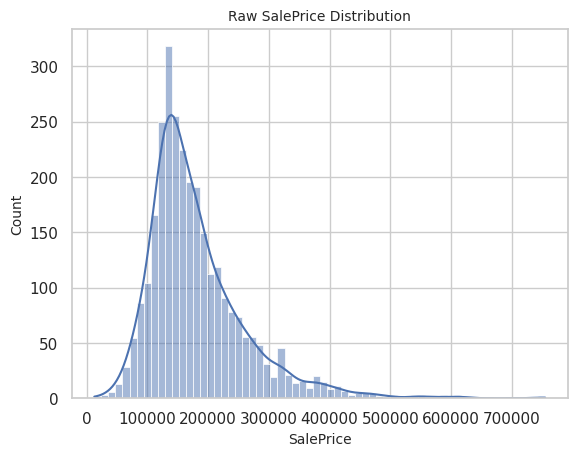

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Visual check
sns.histplot(df[target_feature], kde=True)
plt.title('Raw SalePrice Distribution')
plt.show()

# Fix the skewness
df['LogSalePrice'] = np.log1p(df[target_feature])

**Histogram of all numerical features**

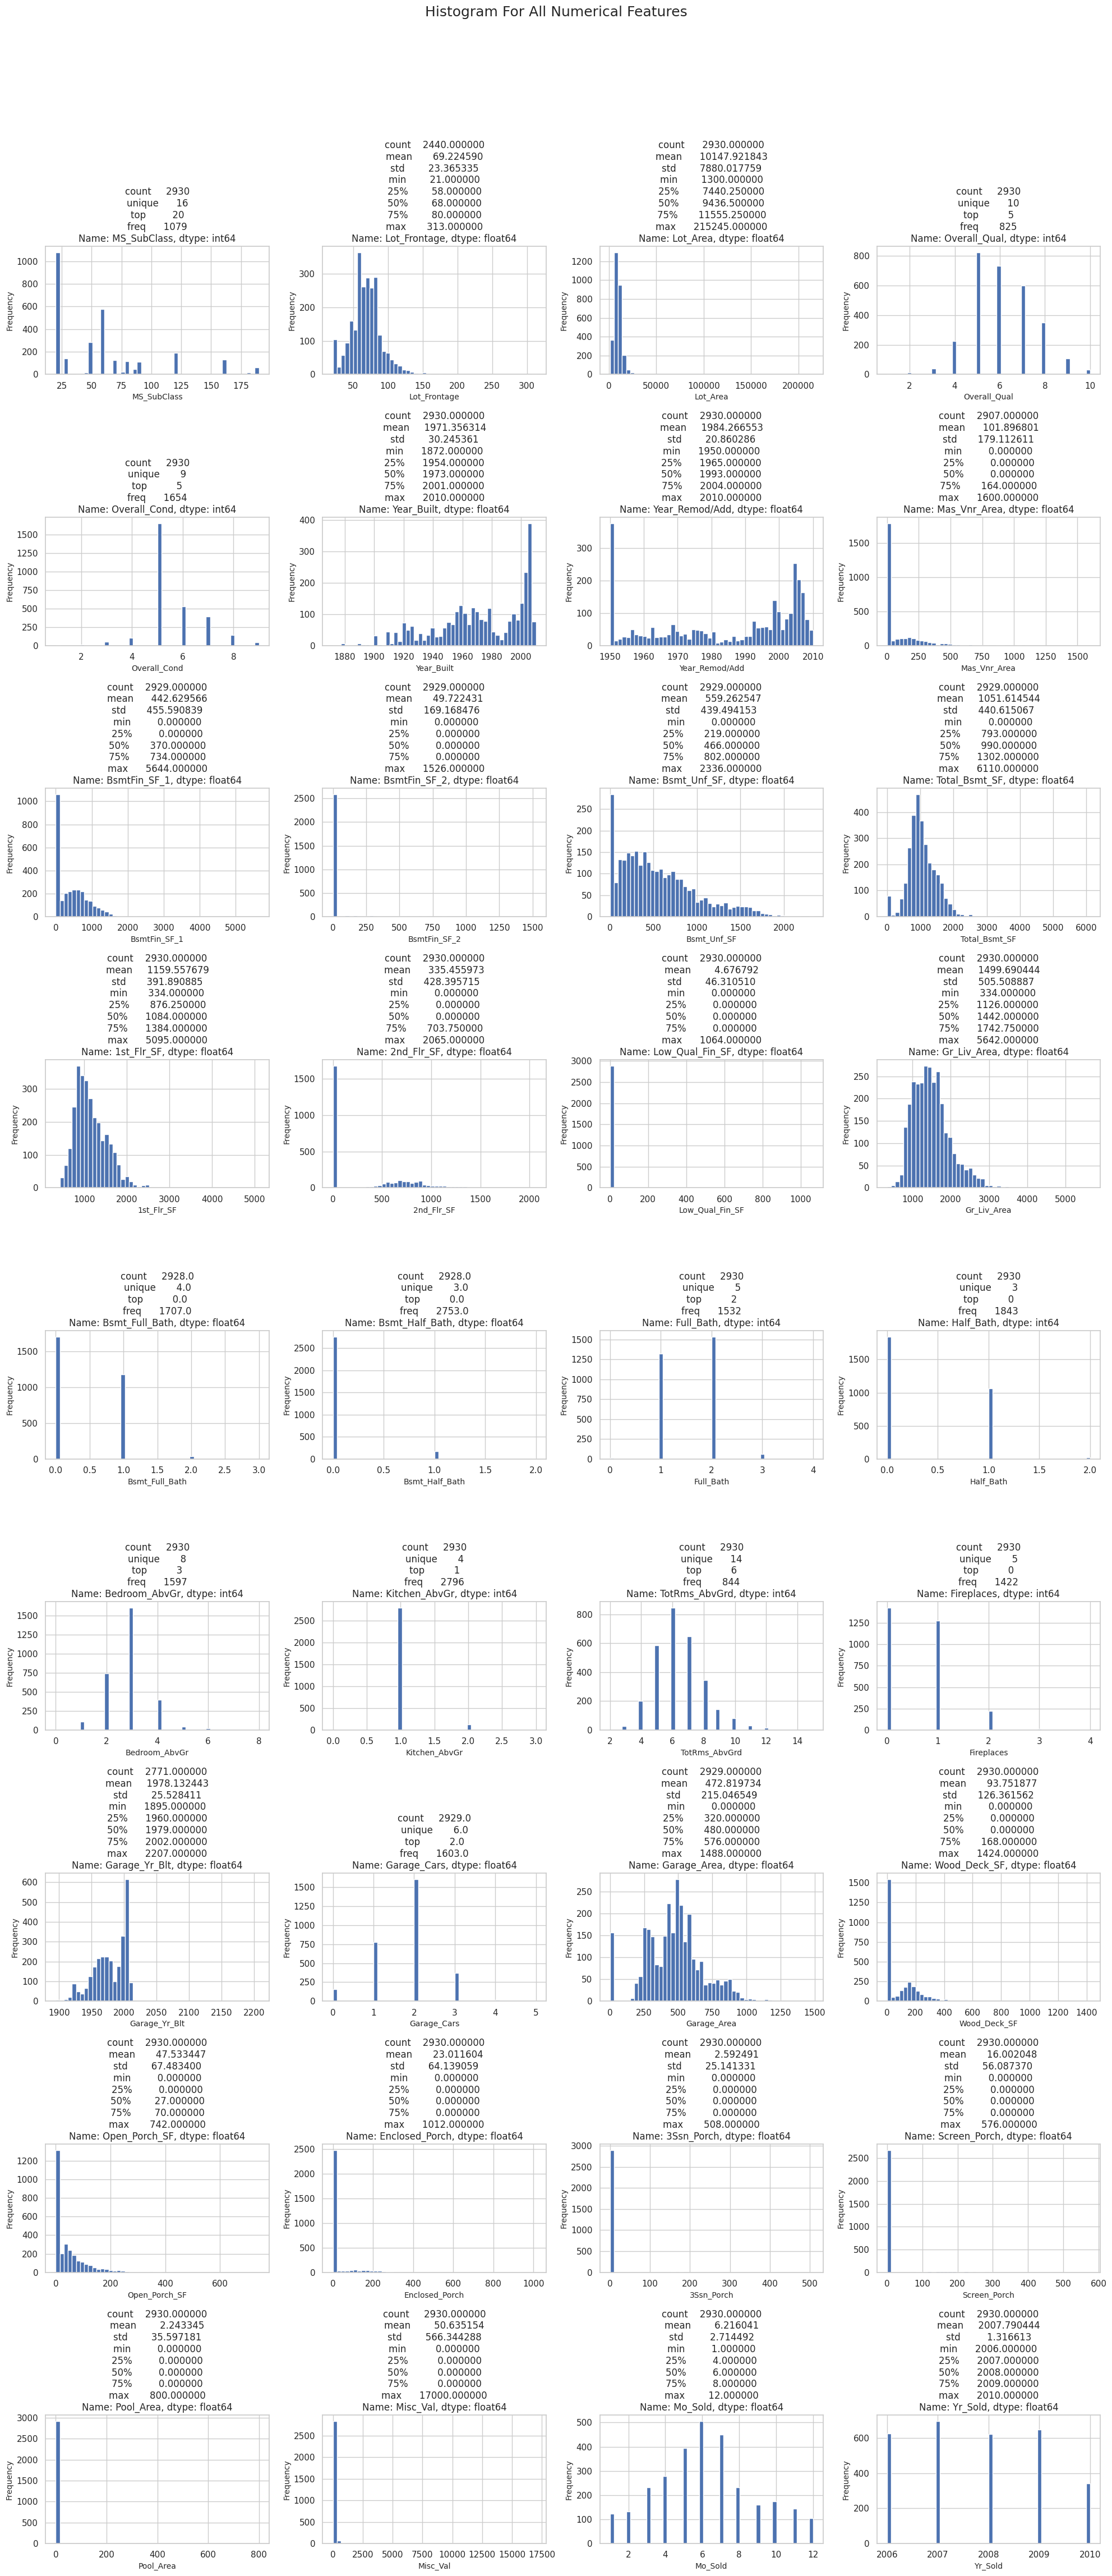

In [112]:
import math

n_cols = 4
n_rows = math.ceil(len(numerical_features) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 5 * n_rows))
axes = axes.ravel()
fig.suptitle("Histogram For All Numerical Features", y=1.02, fontsize=18)

for i, col in enumerate(numerical_features):
    df[col].hist(bins=50, ax=axes[i])
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].set_title(f'{df[col].describe().T}', fontsize=12)

# Remove unused subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [113]:
import math
import plotly.subplots as sp
import plotly.graph_objects as go

n_cols = 4
n_rows = math.ceil(len(numerical_features) / n_cols)

# Create a subplot grid with Plotly
fig = sp.make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=numerical_features,
    vertical_spacing=0.05,
    horizontal_spacing=0.05
)

for i, col in enumerate(numerical_features):
    row = (i // n_cols) + 1
    col_idx = (i % n_cols) + 1

    # Add a histogram for each numerical feature
    fig.add_trace(
        go.Histogram(x=df[col], name=col, nbinsx=50),
        row=row,
        col=col_idx
    )

# Update layout settings for better presentation
fig.update_layout(
    title_text="Interactive Histogram For All Numerical Features",
    height=300 * n_rows,
    width=1200,
    showlegend=False,
    template="plotly_white"
)

fig.show()

**Relationship between Numerical Features and Target Variable**

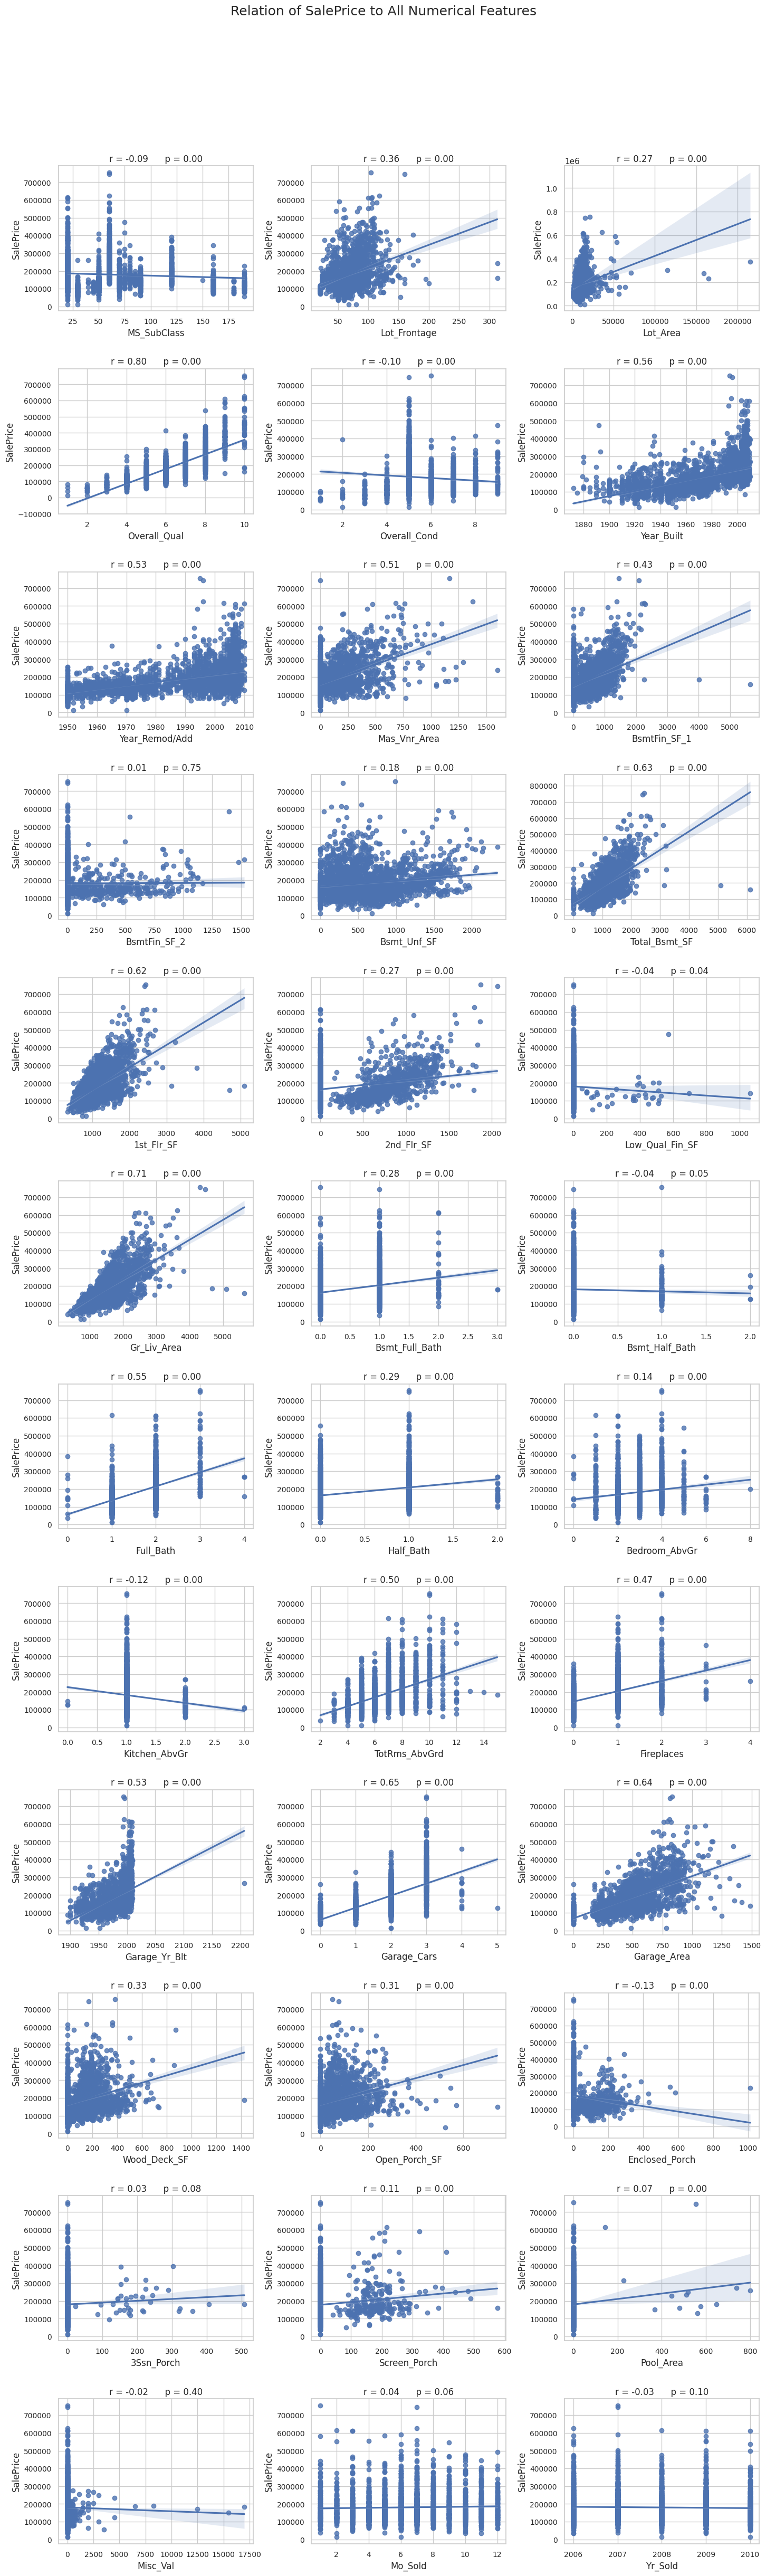

In [114]:
import scipy.stats as stats

sns.set(style="whitegrid", rc={"axes.titlesize": 10, "axes.labelsize": 10})
num_plots = len(numerical_features)
num_cols = 3  # 3 columns
num_rows = (num_plots // num_cols) + (1 if num_plots % num_cols != 0 else 0)

fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows))
axs = axs.ravel()

for i, col in enumerate(numerical_features):
    # Ensure the column is numeric for plotting and correlation calculation
    filtered_df = df[[col, 'SalePrice']].copy()
    filtered_df[col] = pd.to_numeric(filtered_df[col], errors='coerce')
    filtered_df = filtered_df.replace([np.inf, -np.inf], np.nan).dropna()

    sns.regplot(x=filtered_df[col], y=filtered_df['SalePrice'], ax=axs[i])
    stp = stats.pearsonr(filtered_df[col], filtered_df['SalePrice'])
    str_title = f"r = {stp[0]:.2f}      p = {stp[1]:.2f}"
    axs[i].set_title(str_title, fontsize=12)
    axs[i].set_xlabel(col, fontsize=12)
    axs[i].set_ylabel('SalePrice', fontsize=12)
    axs[i].tick_params(axis='both', which='major', labelsize=10)

# Remove any unused axes
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.suptitle('Relation of SalePrice to All Numerical Features', fontsize=18, y=1.02)
plt.tight_layout(pad=2.0, rect=[0, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

**Countplots for all categorical features**

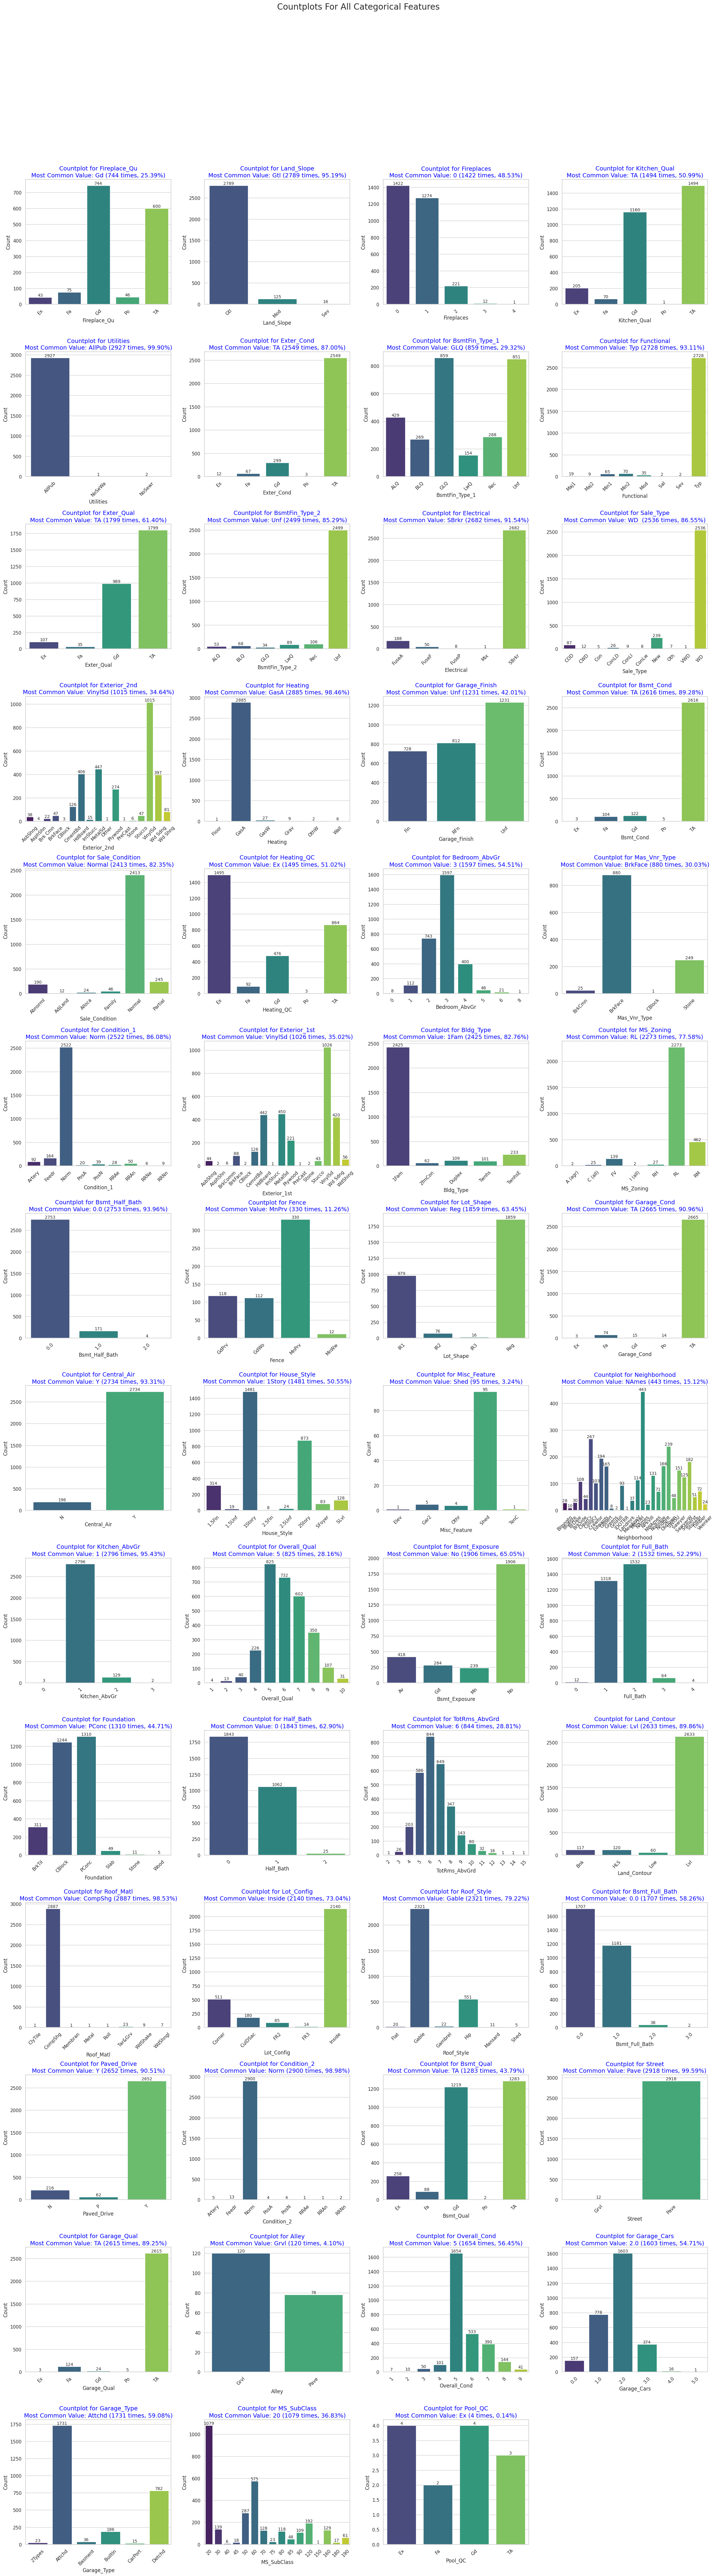

In [115]:
categorical_features = df[categorical_features_all].copy()
categorical_features.columns = [f"{col.strip()}_{i}" if categorical_features.columns.tolist().count(col.strip()) > 1 else col.strip()
                                for i, col in enumerate(categorical_features.columns)]

num_rows = (len(categorical_features.columns) + 3) // 4
fig, axes = plt.subplots(num_rows, 4, figsize=(24, 6 * num_rows))
axes = axes.ravel()
fig.suptitle("Countplots For All Categorical Features", fontsize=20, y=1.02)

for i, col in enumerate(categorical_features.columns):
    ax = axes[i]
    sns.countplot(x=col, data=categorical_features, ax=ax, palette='viridis')
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)

    vc = categorical_features[col].value_counts()
    if not vc.empty:
        values = vc.index[0]
        counts = vc.values[0]
        ax.set_title(f'Countplot for {col}\n'
                     f"Most Common Value: {values} ({counts} times, {counts / len(categorical_features) * 100:,.2f}%)",
                     fontsize=14, color='blue')
        for p in ax.patches:
            ax.annotate(f'{int(p.get_height())}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=10)
    ax.tick_params(axis='x', rotation=45)

for i in range(len(categorical_features.columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

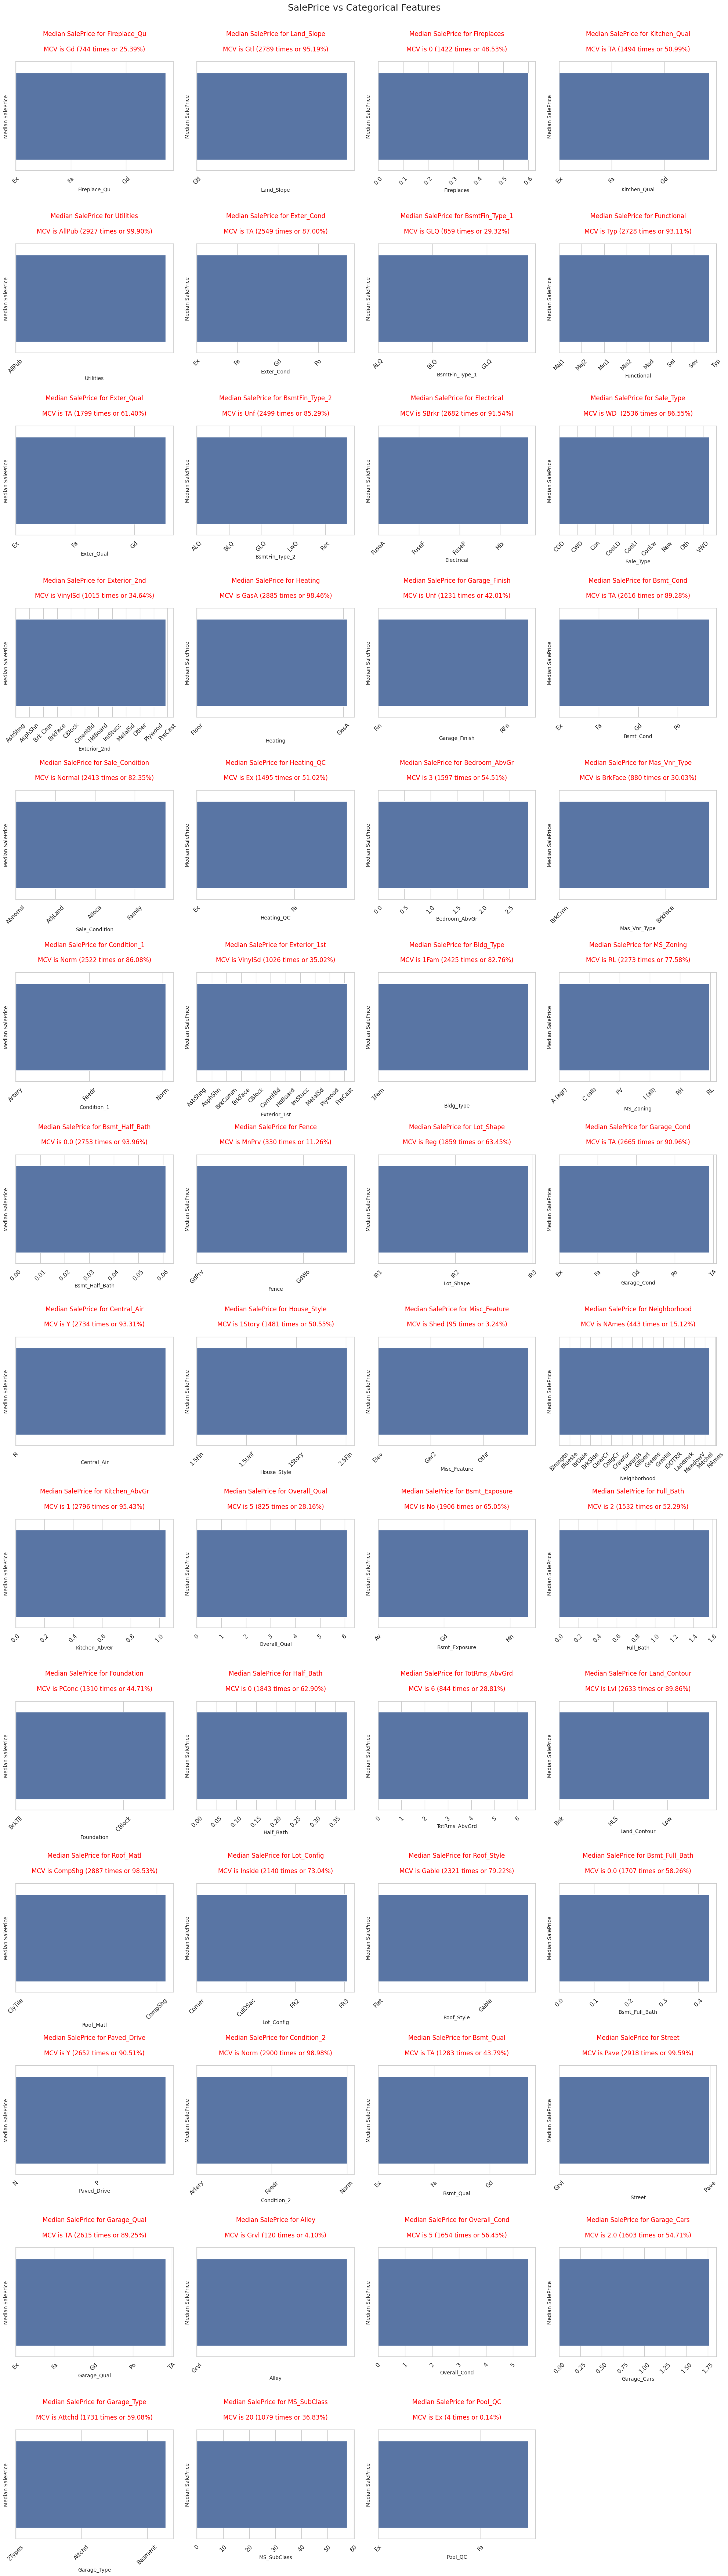

In [116]:
import math

n_cols = 4
n_rows = math.ceil(len(categorical_features.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.ravel()
fig.suptitle("SalePrice vs Categorical Features", y=1.002, fontsize=18)

for i, col in enumerate(categorical_features.columns):
    vc = df.groupby(col)['SalePrice'].median().reset_index()

    # Most common value and corresponding mean SalePrice
    mcv = df[col].value_counts().idxmax()
    mcv_count = df[col].value_counts().max()
    mcv_percent = (mcv_count / len(df)) * 100

    ax = axes[i]
    sns.barplot(x=col, data=df, ax=ax, ci=None)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Median SalePrice', fontsize=10)

    ax.set_title(f'Median SalePrice for {col}\n'
                 "\n"
                 f"MCV is {mcv} ({mcv_count} times or {mcv_percent:,.2f}%)\n"
                 , fontsize=12, color = 'red')

    ax.tick_params(axis='x', rotation=45)

# Remove unused subplots dynamically
for j in range(len(categorical_features.columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Neighbourhood Counts')

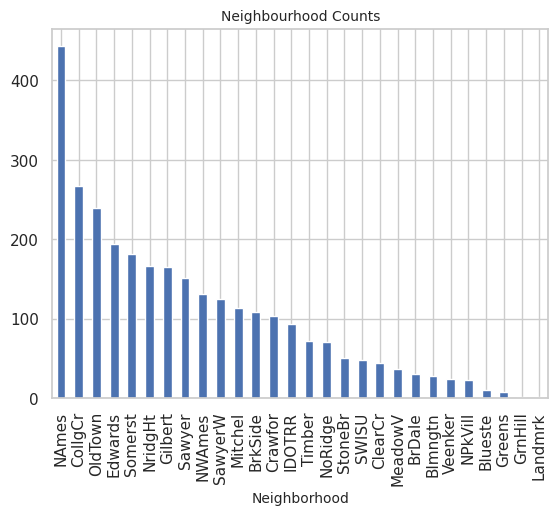

In [117]:
df['Neighborhood'].value_counts().plot(kind='bar')
plt.title('Neighbourhood Counts')

In [118]:
import plotly.express as px

# Reset index creates columns: 'Neighborhood' (values) and 'count' (frequency)
plot_data = df['Neighborhood'].value_counts().reset_index()

fig = px.bar(
    plot_data,
    x='Neighborhood',
    y='count',
    labels={'Neighborhood': 'Neighborhood', 'count': 'Count'},
    title='Neighborhood Counts'
)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

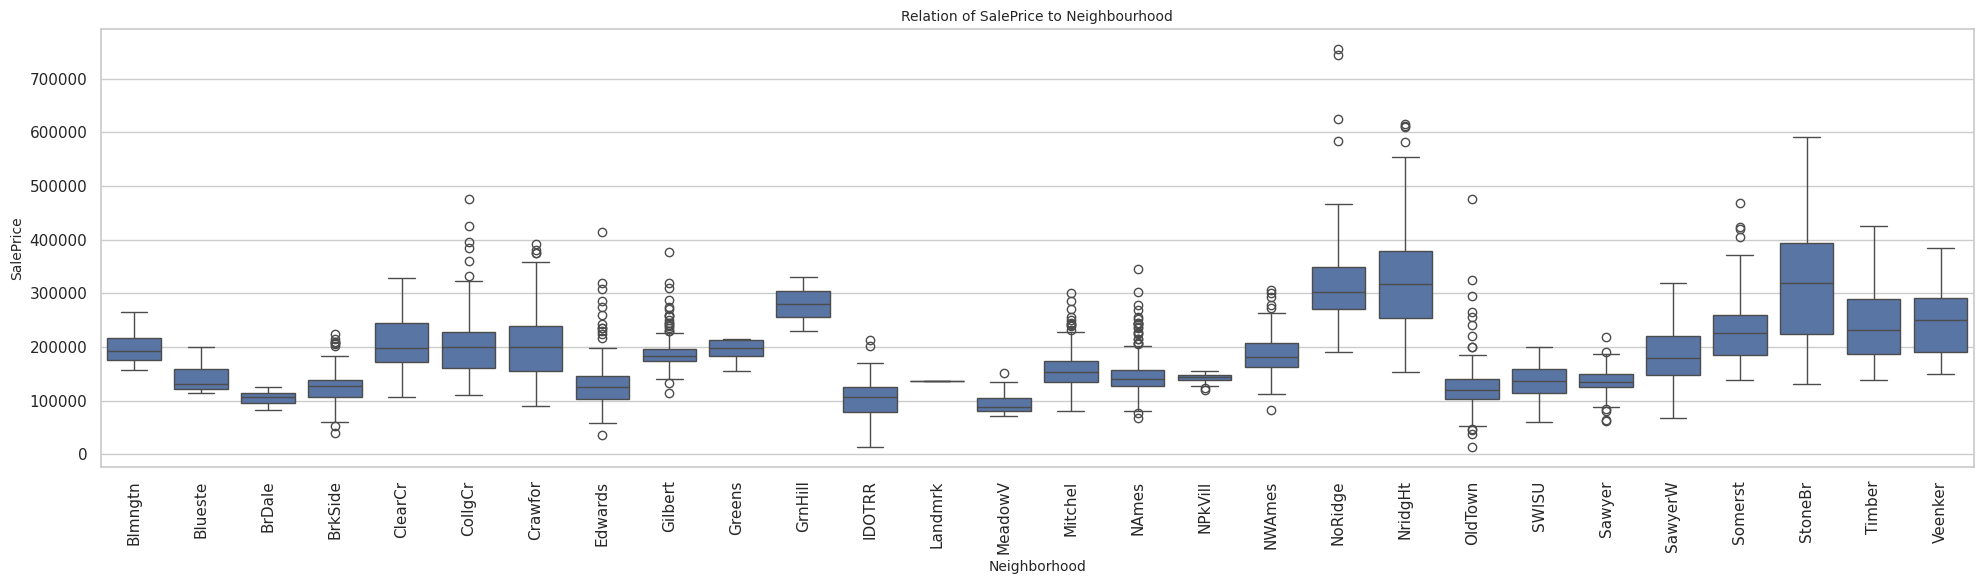

In [119]:
plt.figure(figsize=(20,6))
a = sns.boxplot(x='Neighborhood', y='SalePrice', data=df)
a.tick_params(axis='x', rotation=90)
plt.title('Relation of SalePrice to Neighbourhood')
plt.tight_layout()
plt.show()

In [120]:
import plotly.express as px

# Sort neighborhoods by median SalePrice for a cleaner visual flow
category_order = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index.tolist()

fig = px.box(
    df,
    x='Neighborhood',
    y='SalePrice',
    category_orders={'Neighborhood': category_order},
    title='Relation of SalePrice to Neighborhood (Interactive)',
    labels={'Neighborhood': 'Neighborhood', 'SalePrice': 'Sale Price ($)'},
    color='Neighborhood'
)

fig.update_layout(
    xaxis_tickangle=-45,
    showlegend=False,
    height=600,
    width=1200,
    template='plotly_white'
)

fig.show()

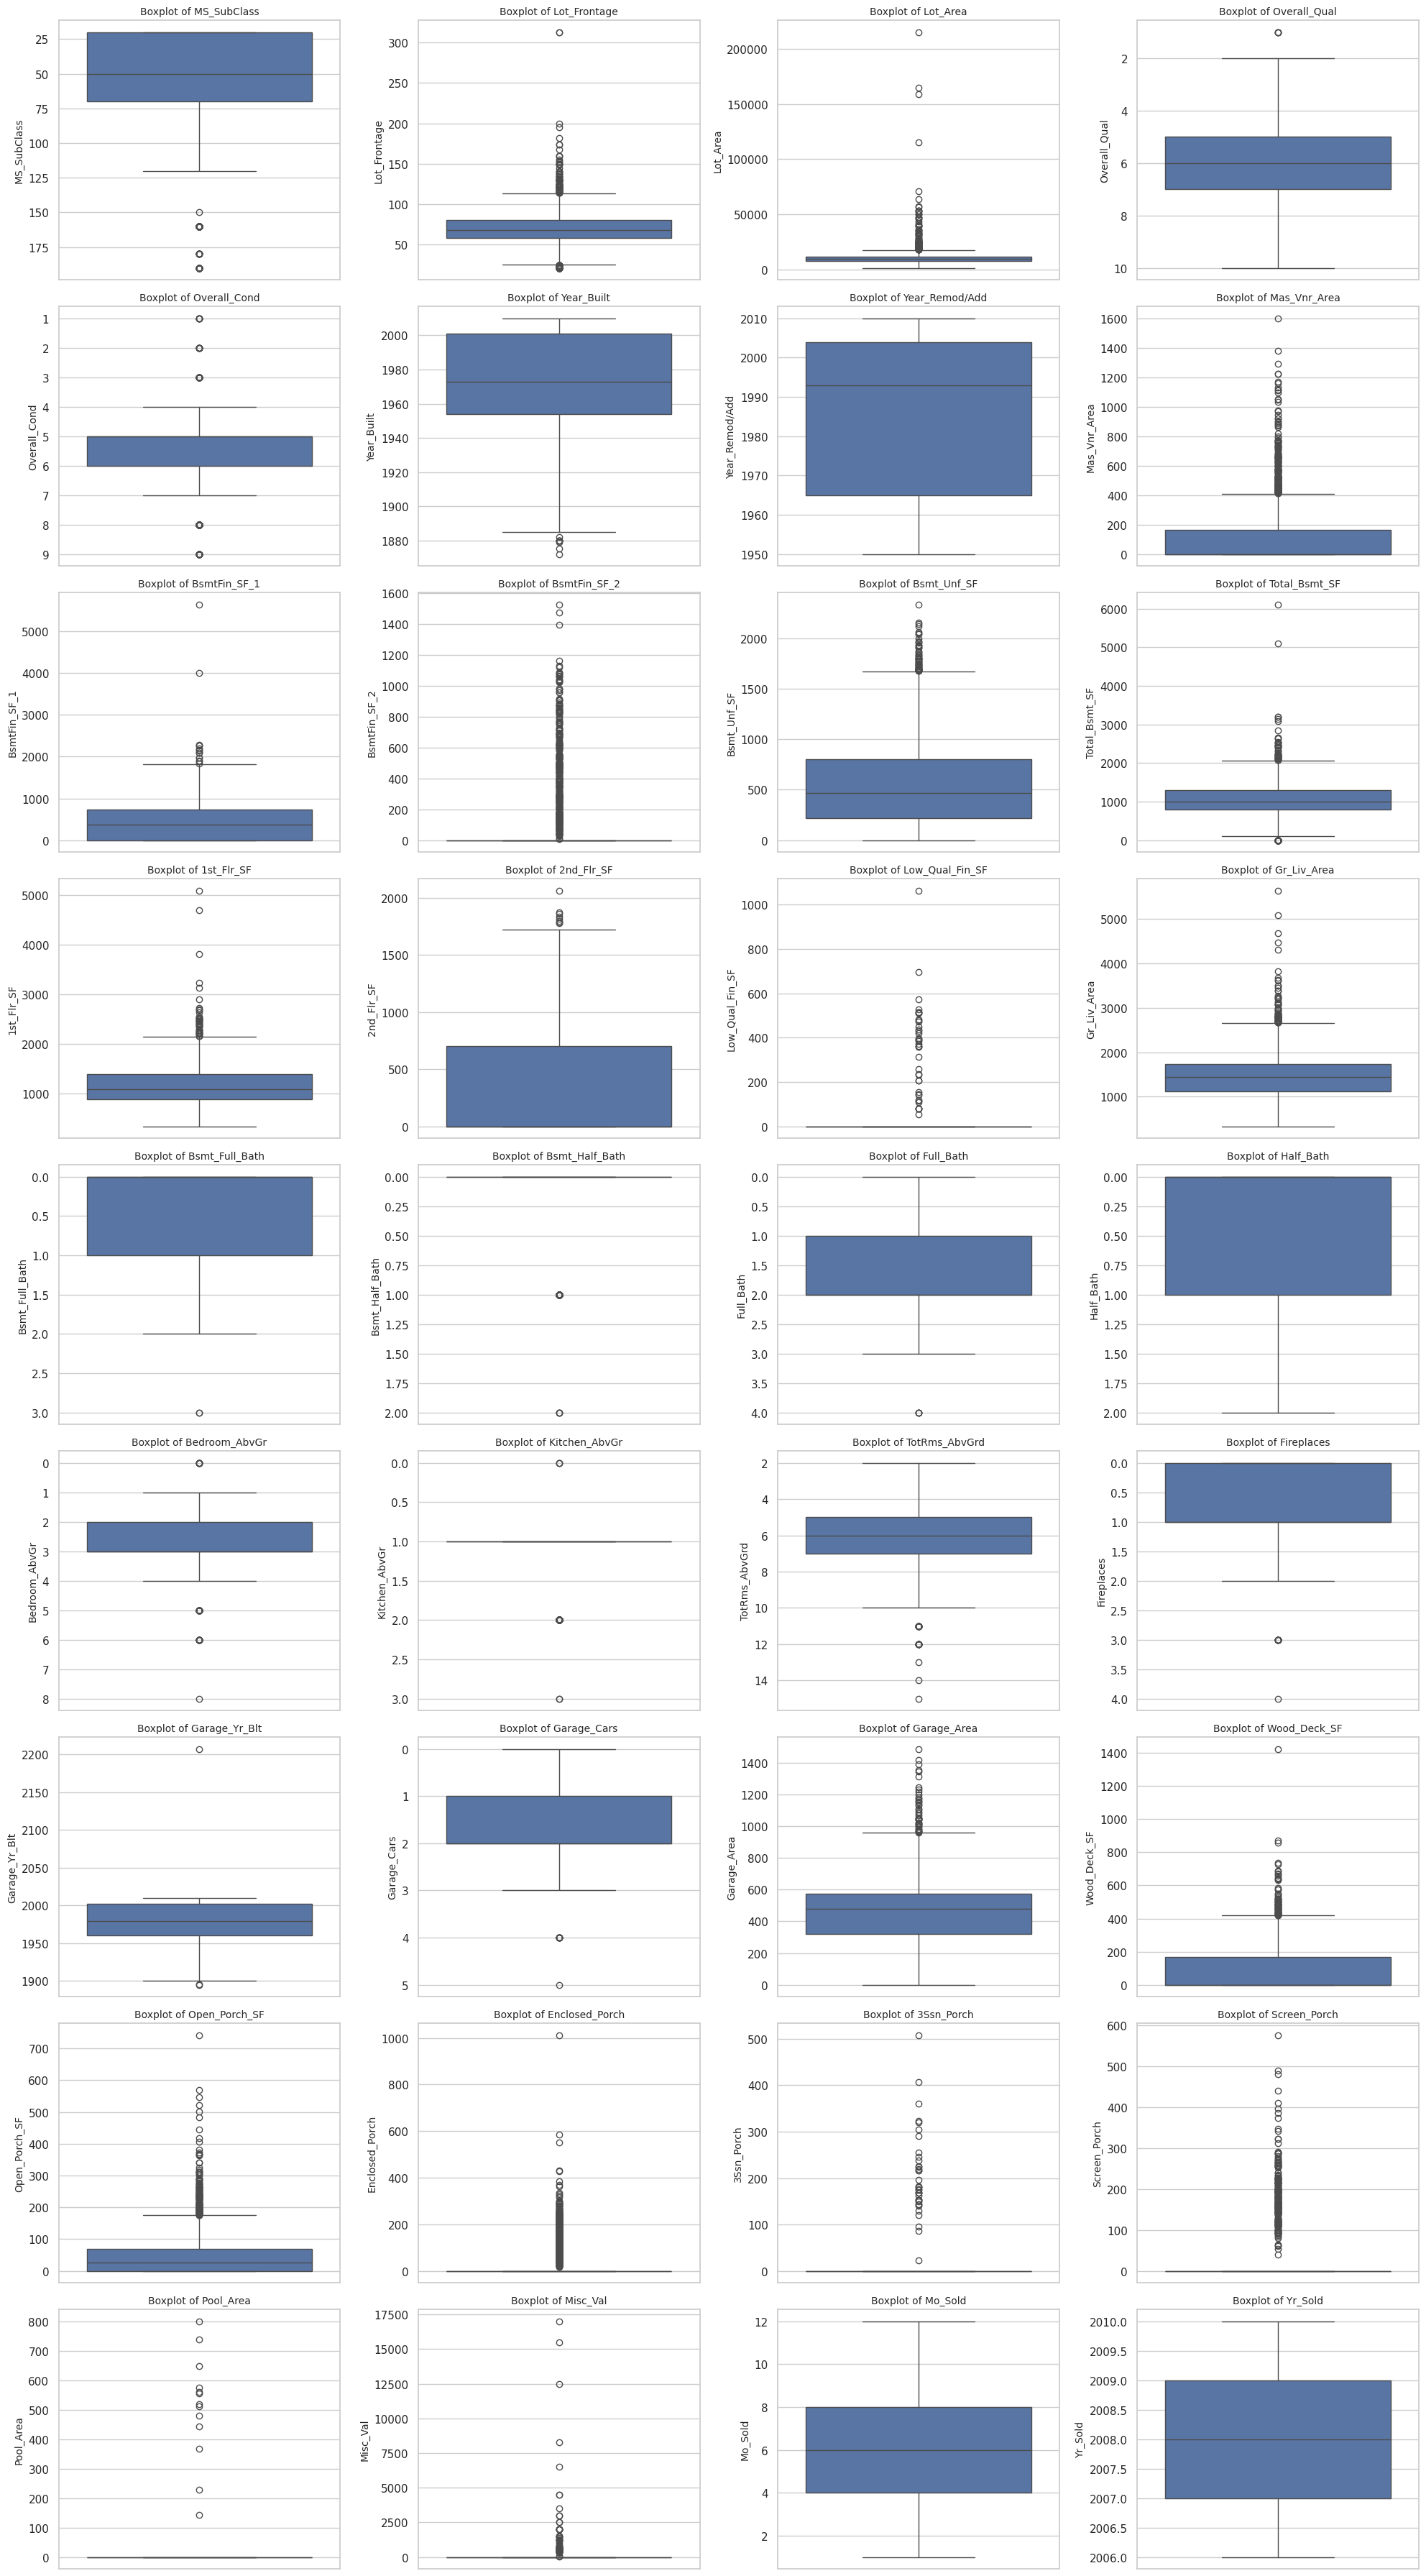

In [123]:
import math

num_columns = df[numerical_features].columns
# Visualizing numerical features for outliers using boxplots

n_cols = 4
n_rows = math.ceil(len(num_columns) / n_cols)

plt.figure(figsize=(20, 4 * n_rows))
for i, col in enumerate(num_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
plt.show()

In [ ]:
import math
import plotly.subplots as sp
import plotly.graph_objects as go

num_columns = df[numerical_features].columns
n_cols = 4
n_rows = math.ceil(len(num_columns) / n_cols)

# Create an interactive subplot grid with Plotly
fig = sp.make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=num_columns,
    vertical_spacing=0.04,
    horizontal_spacing=0.04
)

for i, col in enumerate(num_columns):
    row = (i // n_cols) + 1
    col_idx = (i % n_cols) + 1

    # Add a Box plot for each numerical feature
    fig.add_trace(
        go.Box(y=df[col], name=col, boxpoints='outliers'),
        row=row,
        col=col_idx
    )

# Update layout settings for better presentation
fig.update_layout(
    title_text="Interactive Boxplots For All Numerical Features",
    height=250 * n_rows,
    width=1200,
    showlegend=False,
    template="plotly_white"
)

fig.show()